Prediction (0=fail, 1=Pass): 1


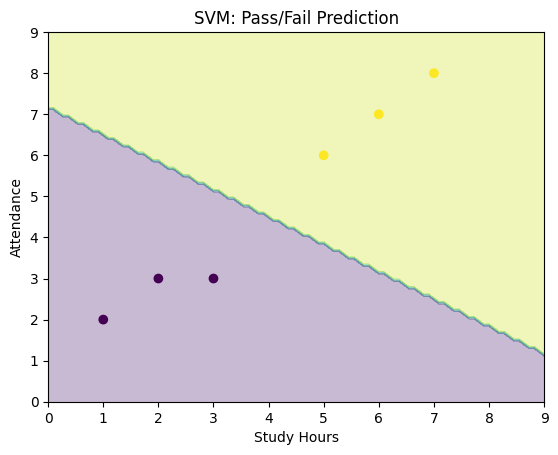

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
X = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [5, 6],
    [6, 7],
    [7, 8]
])
y = np.array([0, 0, 0, 1, 1, 1])
model = SVC(kernel='linear')
model.fit(X, y)
new_student = [[4, 5]]
prediction = model.predict(new_student)
print("Prediction (0=fail, 1=Pass):", prediction[0])
xx, yy = np.meshgrid(np.linspace(0, 9, 100),np.linspace(0, 9, 100))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.title("SVM: Pass/Fail Prediction")
plt.show()

   Study_Hours  Sleep_Hours  Pass
0            1            8     0
1            2            7     0
2            3            7     0
3            4            6     1
4            5            6     1
5            6            5     1
6            7            5     1
7            8            4     1
8            9            4     1
9           10            3     1
Accuracy: 1.0


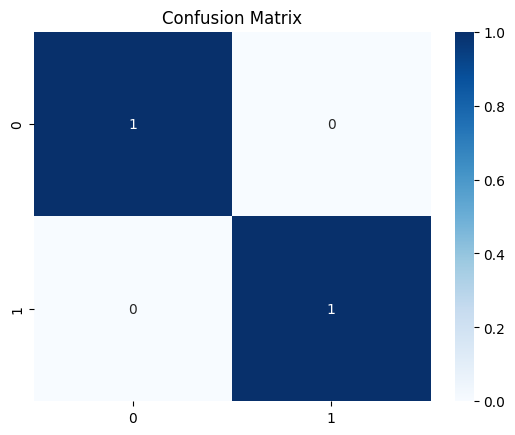

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Dataset
data = {
    "Study_Hours": [1,2,3,4,5,6,7,8,9,10],
    "Sleep_Hours": [8,7,7,6,6,5,5,4,4,3],
    "Pass":        [0,0,0,1,1,1,1,1,1,1]
}

df = pd.DataFrame(data)
print(df)

# Features & Target
X = df[["Study_Hours", "Sleep_Hours"]]
y = df["Pass"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()